# Clustering

**Clustering** algorithms group data into clusters based on **similarity**, without predefined
labels. This is the second major branch of classical unsupervised machine learning, alongside the
[dimensionality reduction](dimensionalityreduction.ipynb) methods we have just covered.

These notes cover:

- clustering versus supervised classification, and what clustering is good for
- the landscape of clustering algorithms, and their trade-offs
- **K-means clustering** — the algorithm, and its failure modes
- how to **choose the number of clusters** (inertia and the elbow method, the silhouette score)
- **DBSCAN**
- **Gaussian Mixture Models**


## Clustering vs. supervised classification

The contrast with supervised classification is the place to start. In classification we already have
labels, and we are predicting them based on known outcomes. In clustering we have **no labels a
priori**, and we are trying to discover the inherent patterns and relationships in the data.


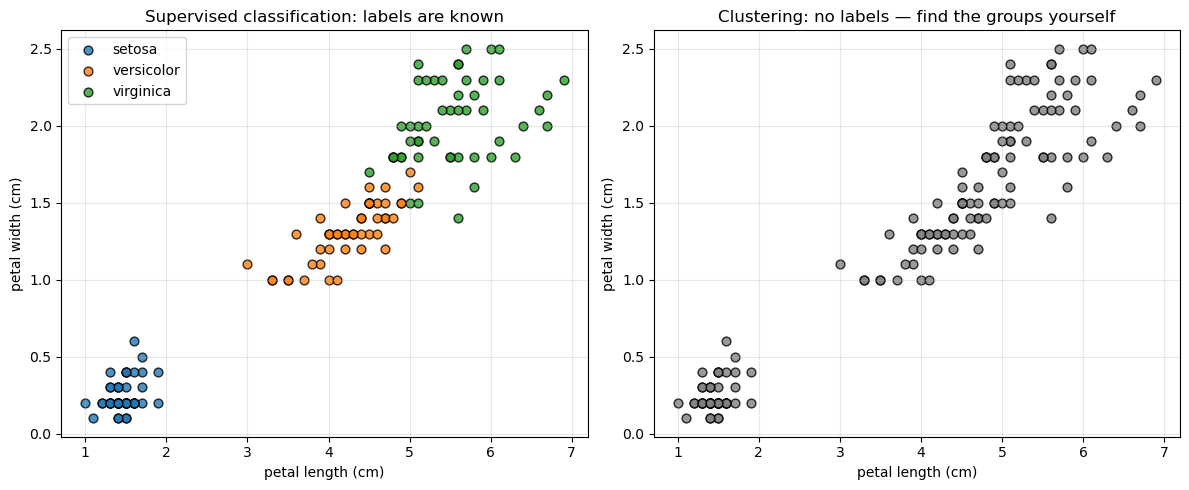

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, 2:4]      # petal length, petal width
y = iris.target

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Supervised: we know the labels, and color by them.
for k, name in enumerate(iris.target_names):
    ax1.scatter(X[y == k, 0], X[y == k, 1], label=name, edgecolor="k", s=40, alpha=0.8)
ax1.set_xlabel("petal length (cm)")
ax1.set_ylabel("petal width (cm)")
ax1.set_title("Supervised classification: labels are known")
ax1.legend()
ax1.grid(alpha=0.3)

# Unsupervised: this is all a clustering algorithm ever sees.
ax2.scatter(X[:, 0], X[:, 1], c="gray", edgecolor="k", s=40, alpha=0.8)
ax2.set_xlabel("petal length (cm)")
ax2.set_ylabel("petal width (cm)")
ax2.set_title("Clustering: no labels — find the groups yourself")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Look at the right-hand panel — that is all a clustering algorithm gets. The bottom-left group
is obviously separate, and any method will find it. But knowing how to split the other two would be
much harder without the labels: they run together. That is the challenge of clustering in a
nutshell.

Clustering is useful for:

- **Data analysis** — discovering structure you didn't know was there
- **Dimensionality reduction**
- **Anomaly detection** — if we have some well-defined clusters and then see points lying well
  outside of them, that suggests anomalous or unusual samples worth analyzing further. In climate
  and environmental science this could be an unusual soil or water sample, an unusual weather
  pattern, or an instrument that has developed a fault and is reporting something not typically
  represented in the data set.


## There are many different clustering algorithms

Different algorithms are built on different principles, and they behave very differently depending
on how your data is actually distributed. The figure below applies four common methods to five
differently-shaped data sets.


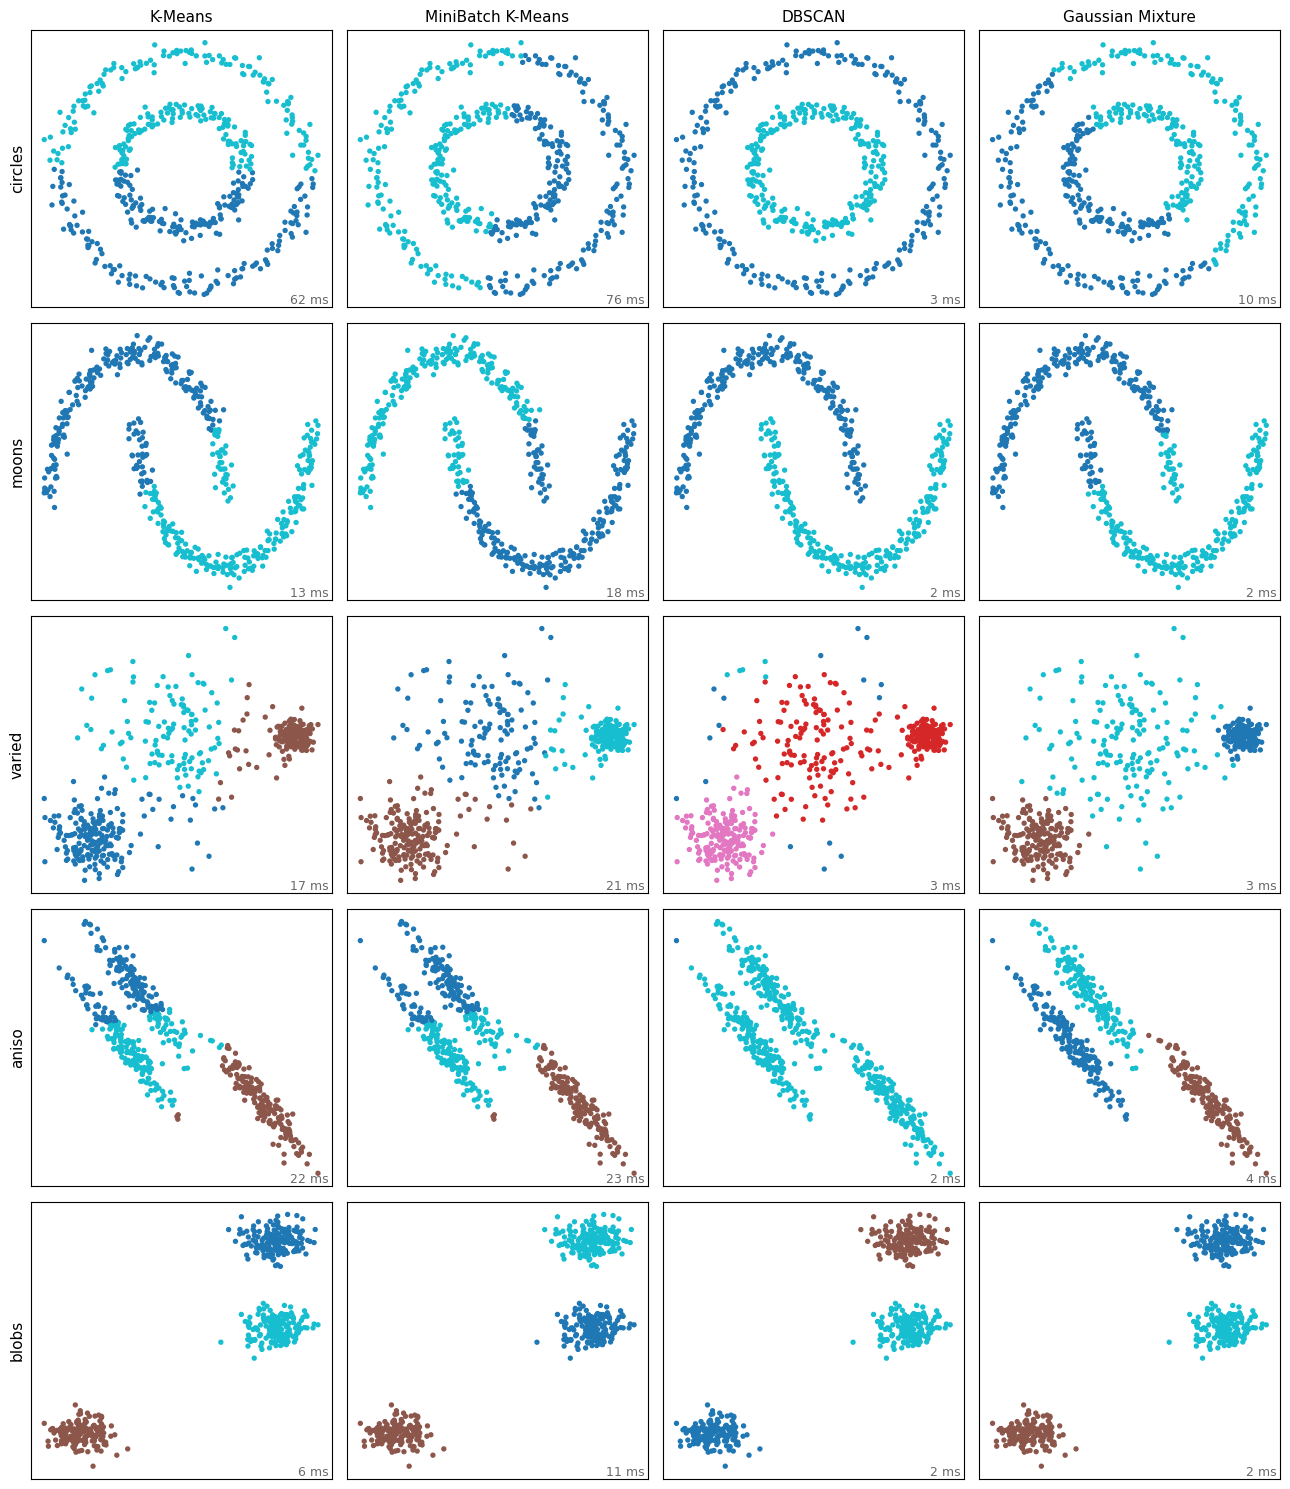

In [2]:
from sklearn import cluster, mixture
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.preprocessing import StandardScaler
import time
import warnings

rng = np.random.default_rng(0)
n = 500

# Five data sets with deliberately different structure.
circles = make_circles(n_samples=n, factor=0.5, noise=0.05, random_state=0)[0]
moons = make_moons(n_samples=n, noise=0.05, random_state=0)[0]
blobs = make_blobs(n_samples=n, random_state=8)[0]
# Anisotropic (stretched, ellipsoidal) blobs
Xa = make_blobs(n_samples=n, random_state=170)[0]
aniso = Xa @ [[0.6, -0.6], [-0.4, 0.8]]
# Blobs with very different variances
varied = make_blobs(n_samples=n, cluster_std=[1.0, 2.5, 0.5], random_state=170)[0]

datasets = [("circles", circles, 2), ("moons", moons, 2), ("varied", varied, 3),
            ("aniso", aniso, 3), ("blobs", blobs, 3)]

algos = ["K-Means", "MiniBatch K-Means", "DBSCAN", "Gaussian Mixture"]

fig, axes = plt.subplots(len(datasets), len(algos), figsize=(13, 15))

for row, (dname, Xd, k) in enumerate(datasets):
    Xd = StandardScaler().fit_transform(Xd)
    models = [
        cluster.KMeans(n_clusters=k, n_init=10, random_state=0),
        cluster.MiniBatchKMeans(n_clusters=k, n_init=10, random_state=0),
        cluster.DBSCAN(eps=0.3),
        mixture.GaussianMixture(n_components=k, covariance_type="full", random_state=0),
    ]
    for col, (aname, model) in enumerate(zip(algos, models)):
        ax = axes[row, col]
        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(Xd)
        elapsed = time.time() - t0
        pred = model.predict(Xd) if hasattr(model, "predict") else model.labels_

        ax.scatter(Xd[:, 0], Xd[:, 1], c=pred, cmap="tab10", s=8)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(aname, size=11)
        if col == 0:
            ax.set_ylabel(dname, size=11)
        # Runtime matters as much as accuracy — note it in the corner.
        ax.text(0.99, 0.01, f"{elapsed*1000:.0f} ms", transform=ax.transAxes,
                size=9, ha="right", color="dimgray")

plt.tight_layout()
plt.show()

Reading across the rows, some methods do much better than others depending on the **shape** of
the clusters and how they sit relative to one another. K-means handles the well-separated `blobs`
beautifully and the `circles` and `moons` terribly. DBSCAN handles the `moons` and `circles` — the
non-convex shapes — but is thrown by `varied`, where cluster densities differ. The Gaussian Mixture
Model handles `aniso`, the stretched clusters, far better than K-means does.

Also note the runtimes in the corner of each panel. This is a real trade-off: a method like
**OPTICS** works well across many of these data sets but is one of the most computationally
expensive available. Depending on how your data points are distributed, how much time you have, and
how large your data set is, some methods will be more usable than others.

We'll cover K-means, DBSCAN, and Gaussian Mixture Models below, but there are many more. It is worth
exploring the [scikit-learn clustering
documentation](https://scikit-learn.org/stable/modules/clustering.html) for whatever data set you
are actually trying to cluster.


## K-means clustering

K-means is one of the classic, older clustering methods, and it has been around a very long time.

The **assumption you must make as the user** is how many clusters are present in the data to begin
with. The number of clusters, $K$, is a **hyperparameter** of the algorithm — the algorithm cannot
tell you it.

Each sample $\mathbf{x}_i$ will be assigned one (and only one) cluster; samples cannot belong to
several clusters at once. We write $C(i)$ for the cluster number of the $i$th observation. Our
dissimilarity measure is the **Euclidean distance** — effectively the vector distance between two
points in feature space.

K-means minimizes the **within-cluster point scatter**:

$$W(C) = \sum_{k=1}^{K} \sum_{C(i)=k} \lVert \mathbf{x}_i - \mathbf{m}_k \rVert^2$$

where $\mathbf{m}_k$ is the mean (the **centroid**) of cluster $k$.

### The algorithm

1. Randomly initialize $K$ initial centroids.
2. Assign each observation $\mathbf{x}_i$ to its nearest centroid.
3. For a given cluster assignment $C$, compute the cluster means:

   $$\mathbf{m}_k = \frac{1}{N_k}\sum_{C(i)=k} \mathbf{x}_i$$

4. For the current set of cluster means, reassign each observation:

   $$C(i) = \arg\min_{1 \le k \le K} \lVert \mathbf{x}_i - \mathbf{m}_k \rVert^2$$

5. Iterate steps 3 and 4 until convergence — until the centroids stop moving.


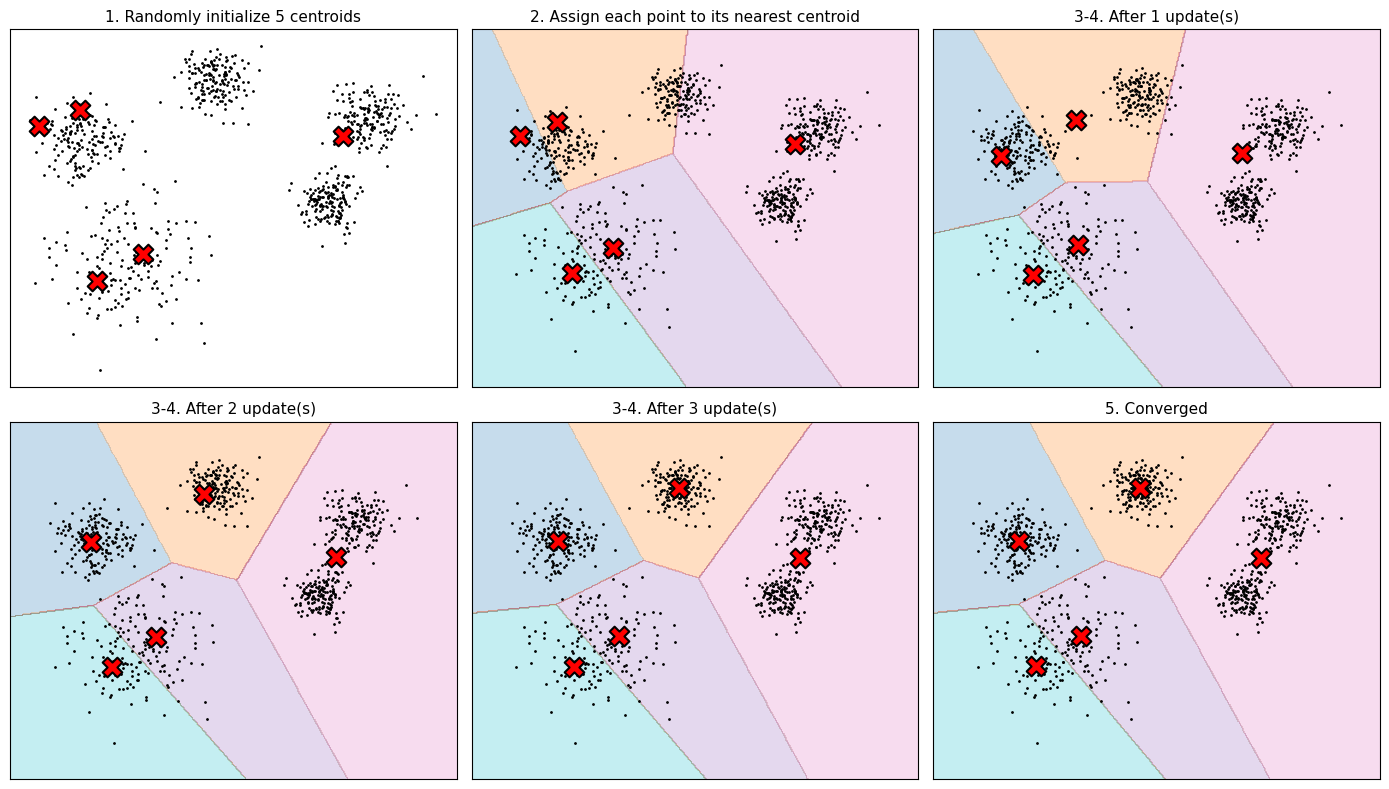

In [3]:
from sklearn.cluster import KMeans

# Five clusters, some more spread out than others. We keep the true labels y5
# only to score the algorithms below — K-means itself never sees them.
X5, y5 = make_blobs(n_samples=800, centers=[[-2.5, 3], [0.5, 4.5], [-1.5, 0],
                                            [3, 1.5], [4, 3.5]],
                    cluster_std=[0.5, 0.4, 0.9, 0.35, 0.4], random_state=7)

def plot_state(ax, X, centroids, title, show_boundaries=True):
    if show_boundaries:
        # Color the plane by which centroid is nearest — the decision boundaries.
        h = 0.03
        xx, yy = np.meshgrid(np.arange(X[:, 0].min()-1, X[:, 0].max()+1, h),
                             np.arange(X[:, 1].min()-1, X[:, 1].max()+1, h))
        grid = np.c_[xx.ravel(), yy.ravel()]
        d = ((grid[:, None, :] - centroids[None, :, :]) ** 2).sum(-1)
        ax.contourf(xx, yy, d.argmin(1).reshape(xx.shape), alpha=0.25, cmap="tab10")
    ax.plot(X[:, 0], X[:, 1], "k.", markersize=2)
    ax.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200,
               c="red", edgecolor="k", linewidth=1.5, zorder=10)
    ax.set_title(title, size=11)
    ax.set_xticks([]); ax.set_yticks([])

# Step through the first few iterations by capping max_iter.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
rng = np.random.default_rng(2)
init = X5[rng.choice(len(X5), 5, replace=False)]   # random initial centroids

plot_state(axes[0, 0], X5, init, "1. Randomly initialize 5 centroids", show_boundaries=False)
plot_state(axes[0, 1], X5, init, "2. Assign each point to its nearest centroid")

for ax, iters in zip([axes[0, 2], axes[1, 0], axes[1, 1]], [1, 2, 3]):
    km = KMeans(n_clusters=5, init=init, n_init=1, max_iter=iters, random_state=0).fit(X5)
    plot_state(ax, X5, km.cluster_centers_, f"3-4. After {iters} update(s)")

km_final = KMeans(n_clusters=5, init=init, n_init=1, random_state=0).fit(X5)
plot_state(axes[1, 2], X5, km_final.cluster_centers_, "5. Converged")

plt.tight_layout()
plt.show()

The shaded regions are the **decision boundaries**: every point in a shaded region is nearer to
that region's centroid than to any other. Watch the centroids march toward the centers of the
clusters as the iterations proceed. Each update recomputes the centroid as the mean of the points
currently assigned to it, which pulls it toward the cluster's true center, which changes the
assignments, and so on until nothing moves. For a data set like this — well-separated, roughly
round, comparable densities — K-means does a good job.


### K-means does not have a unique solution

Because the centroids are **randomly initialized**, running K-means more than once will not give
exactly the same solution. Iteratively minimizing the **inertia** — scikit-learn's name for exactly
the $W(C)$ we wrote down above, the sum of squared distances from every point to its assigned
centroid — does not guarantee a unique answer. The algorithm can settle into different local minima
depending on where it started.


random start 3: inertia =   438.2, agreement with true clusters (ARI) = 0.988
random start 0: inertia =  1250.0, agreement with true clusters (ARI) = 0.718


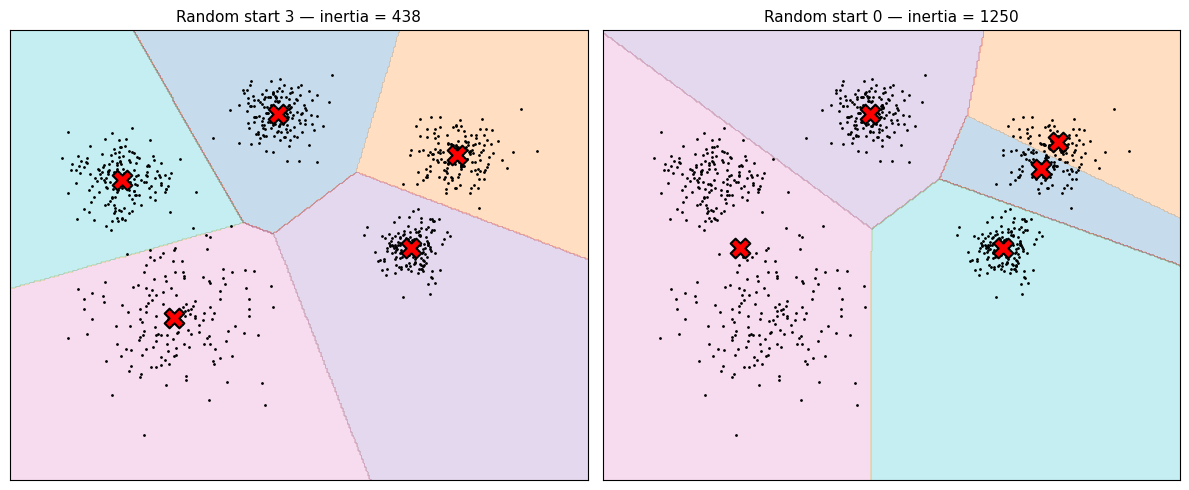

In [4]:
from sklearn.metrics import adjusted_rand_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, seed in zip(axes, [3, 0]):
    rng = np.random.default_rng(seed)
    init = X5[rng.choice(len(X5), 5, replace=False)]
    km = KMeans(n_clusters=5, init=init, n_init=1, random_state=0).fit(X5)
    plot_state(ax, X5, km.cluster_centers_,
               f"Random start {seed} — inertia = {km.inertia_:.0f}")
    # y5 holds the true cluster each point came from. The Adjusted Rand Index
    # scores the clustering against it: 1.0 is a perfect match, 0.0 is random.
    print(f"random start {seed}: inertia = {km.inertia_:7.1f}, "
          f"agreement with true clusters (ARI) = {adjusted_rand_score(y5, km.labels_):.3f}")

plt.tight_layout()
plt.show()

Two different initializations, two genuinely different answers — and one is much worse than
the other. The good run finds the five real clusters almost exactly (ARI 0.99). The bad run gets
stuck in a **local minimum** with nearly three times the inertia: it has balanced a centroid
*between* two real clusters and then split a single real cluster in two to compensate, which is
why it only scores 0.72.

Both are legitimate stopping points for the algorithm — neither can improve by moving a single
centroid. Nothing about the second run is a bug; it is just where that particular random start
happened to lead.

In practice `scikit-learn` guards against this by running the algorithm several times from different
random initializations and keeping the best result — that is what the `n_init` parameter controls.
Above we set `n_init=1` deliberately, to expose the underlying behavior.


## How to choose the number of clusters?

The other challenge is that we have to know $K$ *a priori*, and often we don't. If we are looking at
some environmental variables we have measured, we may have no idea how many classes are actually
represented in the data.


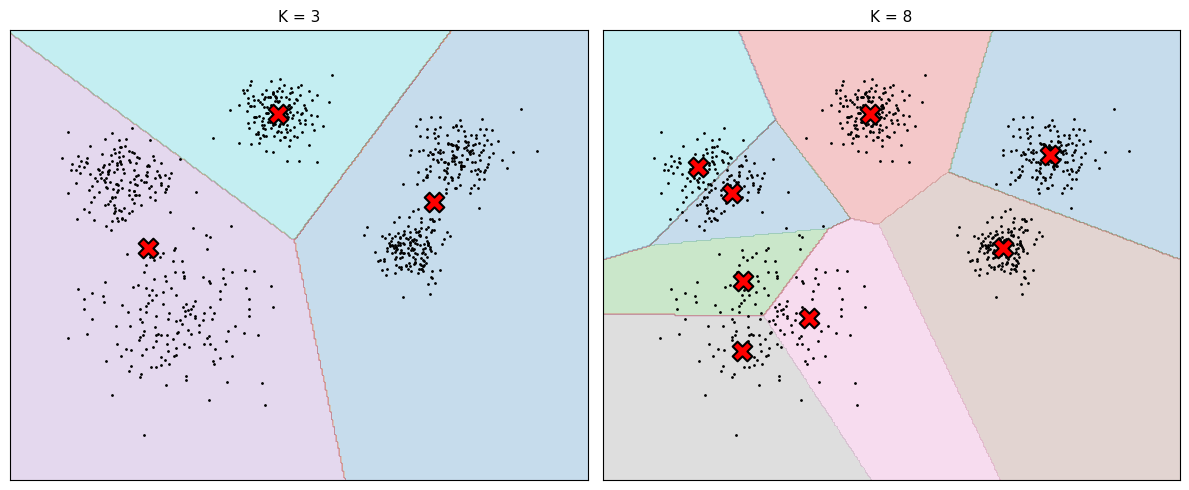

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, k in zip(axes, [3, 8]):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X5)
    plot_state(ax, X5, km.cluster_centers_, f"K = {k}")
plt.tight_layout()
plt.show()

Both of these produce *an* answer. Neither tells you it is the wrong one. So how do we choose?

### The elbow method

Plot the **inertia** — the sum of squared distances from every point to its assigned centroid —
against the number of clusters. Inertia always decreases as $K$ grows (with $K$ equal to the number
of samples it reaches zero), so we can't just minimize it. Instead we look for the **elbow**: the
point where the curve stops dropping steeply and starts decreasing much more slowly.


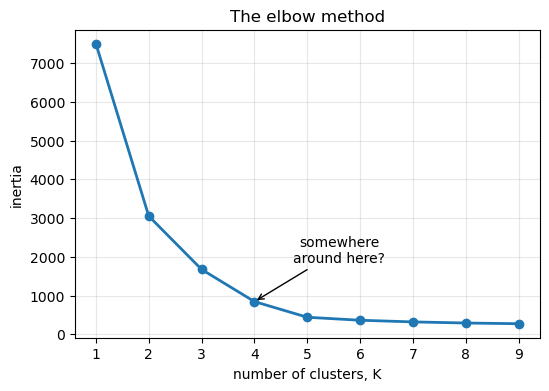

  K :  inertia : drop from K-1
  1 :     7504 :        -
  2 :     3051 :     4453
  3 :     1674 :     1377
  4 :      843 :      831
  5 :      438 :      405
  6 :      361 :       77
  7 :      318 :       43
  8 :      289 :       29
  9 :      271 :       18


In [6]:
ks = list(range(1, 10))
inertias = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X5).inertia_ for k in ks]

plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, "o-", lw=2)
plt.xlabel("number of clusters, K")
plt.ylabel("inertia")
plt.annotate("somewhere\naround here?", xy=(4, inertias[3]), xytext=(5.6, inertias[3] * 2.2),
             arrowprops=dict(arrowstyle="->"), ha="center")
plt.title("The elbow method")
plt.grid(alpha=0.3)
plt.show()

# The bend is easier to judge from how much each extra cluster buys you.
print("  K :  inertia : drop from K-1")
for i, (k, v) in enumerate(zip(ks, inertias)):
    drop = f"{inertias[i-1] - v:8.0f}" if i else "       -"
    print(f"  {k} : {v:8.0f} : {drop}")

The inertia has an elbow, but **it is not always enough to objectively choose $K$**.

Look at the printed drops rather than the picture. Going from 4 to 5 clusters still buys a
substantial reduction in inertia (~405), and only after $K=5$ does the curve really flatten (~77).
So the bend is arguably at 5 — which is what we built. But the bend is **gradual**, and that is the
problem: reading this curve by eye you could justify 4 or 5, and a standard automated knee-finding
rule applied to it actually returns **3**. The elbow gives you a *range*, not an answer.

This is worse when clusters have different **densities**, as they do here: some are tightly packed
and some are spread out, and inertia is dominated by the spread-out ones, which keep rewarding extra
splits regardless of the true cluster count.

### The silhouette score

An alternative is the **silhouette score**, which balances the distance to a point's own cluster
against its distance to the nearest other cluster. For a single sample:

$$s = \frac{b - a}{\max(a, b)}$$

where

- $a$ = the **mean distance to the other instances in the same cluster** (how tight its own cluster
  is around it)
- $b$ = the **mean nearest-cluster distance** — the mean distance to the instances of the closest
  cluster that the sample is *not* part of

The score ranges from $-1$ to $+1$. A value near $+1$ means the sample is comfortably inside its own
cluster and far from the next one; near $0$ means it sits on a boundary; negative means it has
probably been assigned to the wrong cluster. We average this over all samples.


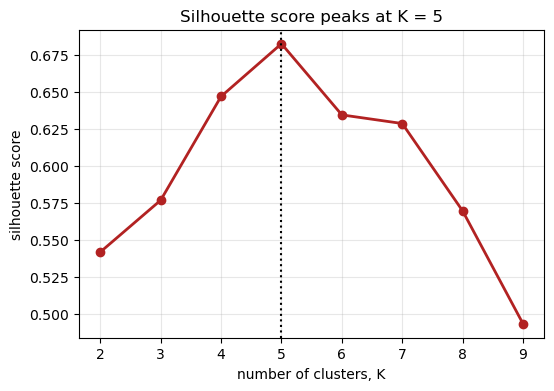

silhouette score by K:
  K = 2: 0.542
  K = 3: 0.577
  K = 4: 0.647
  K = 5: 0.682
  K = 6: 0.634
  K = 7: 0.629
  K = 8: 0.570
  K = 9: 0.494


In [7]:
from sklearn.metrics import silhouette_score

ks = range(2, 10)
sil = [silhouette_score(X5, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X5))
       for k in ks]

plt.figure(figsize=(6, 4))
plt.plot(ks, sil, "o-", lw=2, color="firebrick")
best = ks[int(np.argmax(sil))]
plt.axvline(best, ls=":", c="k")
plt.xlabel("number of clusters, K")
plt.ylabel("silhouette score")
plt.title(f"Silhouette score peaks at K = {best}")
plt.grid(alpha=0.3)
plt.show()

print("silhouette score by K:")
for k, s in zip(ks, sil):
    print(f"  K = {k}: {s:.3f}")

The silhouette score peaks **unambiguously at 5** — the number of clusters we actually built
into the data — and by a clear margin over its neighbors (0.682 against 0.647 at $K=4$). Where the
inertia curve gave us a soft bend we had to squint at, the silhouette score gives us a maximum we can
just read off. That is what makes it the more objective of the two.

It is not infallible — it is still a heuristic, and it has its own bias toward convex, well-separated
clusters. But when the elbow is ambiguous, the silhouette score is usually the better guide.


### Advantages and disadvantages of K-means

K-means is **fast and scalable**, and it is a very simple algorithm to use. But it can struggle with
clusters of **varying sizes**, **varying densities**, and **non-spherical shapes**.

Variants such as **accelerated K-means** and **mini-batch K-means** improve on efficiency, speed,
and scalability, but they don't change the underlying assumptions.


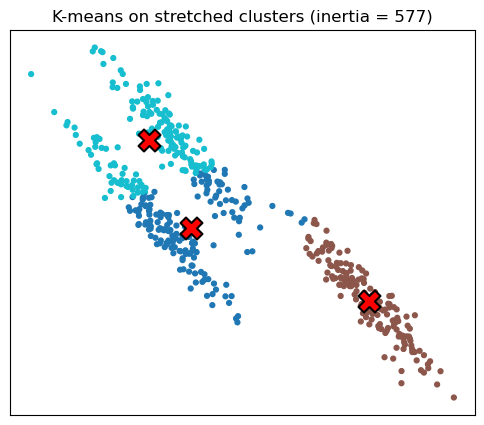

agreement with the true clusters (ARI) = 0.555


In [8]:
# Ellipsoidal (anisotropic) clusters — K-means' classic failure case.
Xa_raw, ya_raw = make_blobs(n_samples=500, random_state=170)
X_aniso = Xa_raw @ [[0.6, -0.6], [-0.4, 0.8]]

km_a = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_aniso)

plt.figure(figsize=(6, 5))
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=km_a.labels_, cmap="tab10", s=12)
plt.scatter(km_a.cluster_centers_[:, 0], km_a.cluster_centers_[:, 1],
            marker="X", s=250, c="red", edgecolor="k", linewidth=1.5, zorder=10)
plt.title(f"K-means on stretched clusters (inertia = {km_a.inertia_:.0f})")
plt.xticks([]); plt.yticks([])
plt.show()

print(f"agreement with the true clusters (ARI) = "
      f"{adjusted_rand_score(ya_raw, km_a.labels_):.3f}")

These clusters are stretched and skewed rather than round. K-means slices across them, placing
centroids *between* the true clusters, because it is minimizing squared distance to a center and has
no concept of a cluster having a *direction*.

Note what the ARI is telling us. K-means converged happily and reported a perfectly respectable
inertia — by its own objective, nothing went wrong. But scored against the clusters that are
actually there, it only manages about 0.56. **A low inertia does not mean a good clustering**; it
only means the algorithm did well at the thing it was optimizing, which is not the same thing.

K-means works best when clusters have **similar densities**, are **reasonably well separated**, and
are **roughly spherical** — the `blobs` case in the comparison figure above. Once you have more
complex shapes or differing densities, you need something else.


## DBSCAN

**DBSCAN** — Density-Based Spatial Clustering of Applications with Noise — takes a different
approach. It finds **core samples of high density** and then expands clusters outward from them.
Where K-means is top-down (start with $K$ centers, assign everything), DBSCAN is **bottom-up**: find
the dense regions of the data set, then grow them by adding neighboring points.

DBSCAN works well when the data contains clusters of **similar density**, separated by regions of
**lower density**.

Its key hyperparameter is **`eps`**: the maximum distance between two samples for one to be
considered a **neighbor** of the other. This is the most important parameter to get right for
DBSCAN, and it makes a large difference.


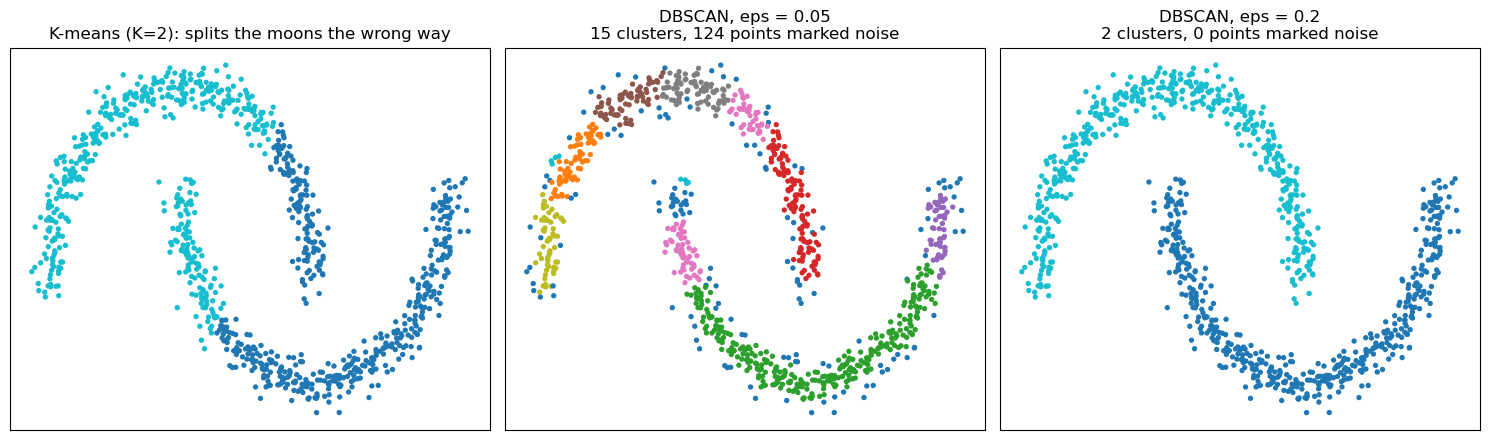

In [9]:
from sklearn.cluster import DBSCAN

X_moons, _ = make_moons(n_samples=1000, noise=0.06, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# K-means for reference: it cannot handle non-convex shapes.
km_m = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X_moons)
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=km_m.labels_, cmap="tab10", s=8)
axes[0].set_title("K-means (K=2): splits the moons the wrong way")

for ax, eps in zip(axes[1:], [0.05, 0.2]):
    db = DBSCAN(eps=eps).fit(X_moons)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = (db.labels_ == -1).sum()
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=db.labels_, cmap="tab10", s=8)
    ax.set_title(f"DBSCAN, eps = {eps}\n{n_clusters} clusters, {n_noise} points marked noise")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In contrast to K-means, DBSCAN does a good job of capturing these **u-shaped** clusters, which
K-means simply cannot — a straight decision boundary can't wrap around a crescent.

But look at the effect of `eps`. Set too low (middle panel), DBSCAN tries to break each moon into
many separate sub-clusters, finding far more clusters than are really there. Set appropriately
(right panel), it identifies the two real clusters cleanly. Setting these hyperparameters correctly
makes a big difference to how well the algorithm performs.

DBSCAN is also **robust to outliers**, more so than K-means. It is allowed to label a point as
belonging to *no* cluster at all — those are the "noise" points counted above. K-means, by contrast,
always uses every point in the data set, because it recalculates centroids as means; a few distant
outliers can drag a centroid away and throw off the whole clustering. DBSCAN just excludes a point
that is too far from any cluster and where the density is too low. If your data set has outliers,
DBSCAN may be preferable.


## Gaussian Mixture Models

A **Gaussian Mixture Model (GMM)** is a **probabilistic** model that assumes all data points are
generated from a mixture of a finite number of Gaussian distributions with unknown parameters.

You can think of a GMM as a **generalization of K-means** that also includes information about the
**covariance structure** of the data. K-means only knows where a cluster's center is. A GMM also
knows its *shape* and *orientation* — so a cluster that has been stretched and skewed relative to a
typical Gaussian is still something it can represent.

In practice, that means a GMM handles the ellipsoidal clusters that defeated K-means.


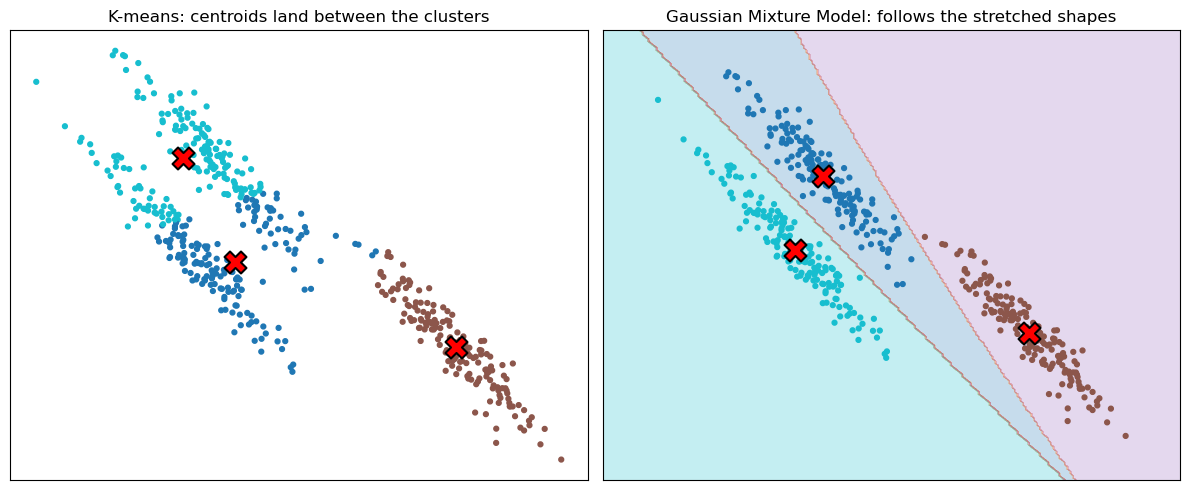

on the same stretched clusters:
  K-means          ARI = 0.555
  Gaussian Mixture ARI = 1.000


In [10]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42).fit(X_aniso)
labels_gmm = gmm.predict(X_aniso)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_aniso[:, 0], X_aniso[:, 1], c=km_a.labels_, cmap="tab10", s=12)
ax1.scatter(km_a.cluster_centers_[:, 0], km_a.cluster_centers_[:, 1],
            marker="X", s=250, c="red", edgecolor="k", linewidth=1.5, zorder=10)
ax1.set_title("K-means: centroids land between the clusters")

# Shade the GMM's decision boundaries so the comparison is like-for-like.
h = 0.05
xx, yy = np.meshgrid(np.arange(X_aniso[:, 0].min()-1, X_aniso[:, 0].max()+1, h),
                     np.arange(X_aniso[:, 1].min()-1, X_aniso[:, 1].max()+1, h))
Z = gmm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z, alpha=0.25, cmap="tab10")
ax2.scatter(X_aniso[:, 0], X_aniso[:, 1], c=labels_gmm, cmap="tab10", s=12)
ax2.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker="X", s=250,
            c="red", edgecolor="k", linewidth=1.5, zorder=10)
ax2.set_title("Gaussian Mixture Model: follows the stretched shapes")

for ax in (ax1, ax2):
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("on the same stretched clusters:")
print(f"  K-means          ARI = {adjusted_rand_score(ya_raw, km_a.labels_):.3f}")
print(f"  Gaussian Mixture ARI = {adjusted_rand_score(ya_raw, labels_gmm):.3f}")

This is the same data set that K-means struggled with. Where K-means put its centroids
between the ellipsoidal clusters and scored about 0.56, the GMM recovers the true clusters
**exactly** — because it can model the covariance, the stretch and tilt, of each one.

A GMM is also *probabilistic*: rather than a hard assignment, `predict_proba` gives you the
probability that each point belongs to each cluster, which is useful when you want to express
uncertainty about boundary cases. (On this particular data set the clusters are well enough
separated that almost every point is assigned with near-total confidence, so there is little
uncertainty to look at — but the machinery is there when your clusters do overlap.)

As with everything here, it depends on your specific data: how the points are laid out in your
clusters, and what shape those clusters are.

## Summary

| Method | Key hyperparameter | Good at | Struggles with |
|---|---|---|---|
| **K-means** | `n_clusters` | Fast, scalable, round well-separated clusters of similar density | Varying sizes/densities, non-spherical shapes, outliers; no unique solution |
| **DBSCAN** | `eps` | Non-convex shapes; robust to outliers; finds its own cluster count | Clusters of differing density; sensitive to `eps` |
| **Gaussian Mixture** | `n_components` | Ellipsoidal clusters; covariance structure; probabilistic assignments | Still assumes Gaussian components; need to choose the component count |

There are a number of different clustering methods beyond these three, built on different principles
and suited to different data. Explore the [scikit-learn
documentation](https://scikit-learn.org/stable/modules/clustering.html) for the data set you are
working with.

Recall too that clustering is often used **in combination with**
[dimensionality reduction](dimensionalityreduction.ipynb): first find a transformation into a space
where the classes separate more easily, then cluster in that space. Together they give us
**unsupervised classification**, without ever starting from labeled data.
